In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('/kaggle/input/sentiment-dataset/urdu_news_with_sentiment2.csv')

In [3]:
df.head()

,Sr. No.,News Items,Label,Sentiment
0,1,ٹی ٹی پی نے پنجاب حکومت کے ہیلی کاپٹر کے عملے ...,FAKE,Negative
1,2,مارک زکربرگ سیاست میں آنے کا سوچ رہے ہیں۔,FAKE,Positive
2,3,فریدہ جلال نے اپنی موت کی افواہوں پر تنقید کی۔,FAKE,Negative
3,4,جعلی خبریں: پاپ اسٹار حدیقہ کیانی نے جعلی منشی...,FAKE,Negative
4,5,صنم ماروی نے میڈیا پر گردش کرنے والی زیادتی او...,FAKE,Negative


In [4]:
df.shape

(10084, 4)

In [5]:
df.drop(columns=['Sr. No.','Label'],inplace=True)

In [6]:
df

,News Items,Sentiment
0,ٹی ٹی پی نے پنجاب حکومت کے ہیلی کاپٹر کے عملے ...,Negative
1,مارک زکربرگ سیاست میں آنے کا سوچ رہے ہیں۔,Positive
2,فریدہ جلال نے اپنی موت کی افواہوں پر تنقید کی۔,Negative
3,جعلی خبریں: پاپ اسٹار حدیقہ کیانی نے جعلی منشی...,Negative
4,صنم ماروی نے میڈیا پر گردش کرنے والی زیادتی او...,Negative
...,...,...
10079,بے روزگاری الاؤنس، کیش بیک اسکیمیں - کانگریس ن...,Negative
10080,چدمبرم نے بجٹ پر تنقید کی، حکومت کا کہنا ہے کہ...,Negative
10081,"نتیش نے بہار میں 16,443 کلومیٹر طویل انسانی زن...",Negative
10082,بھارت کے نوجوان معروف سوشل میڈیا اسٹار اور کام...,Negative


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10084 entries, 0 to 10083
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   News Items  10084 non-null  object
 1   Sentiment   10084 non-null  object
dtypes: object(2)
memory usage: 157.7+ KB


In [8]:
df['Sentiment'].unique()

array(['Negative', 'Positive', 'Neutral', 'Error'], dtype=object)

In [9]:
df['Sentiment'].value_counts()

Sentiment
Negative    6440
Positive    2724
Neutral      791
Error        129
Name: count, dtype: int64

In [10]:
df=df[df['Sentiment']!='Error']

In [11]:
df['Sentiment'].unique()

array(['Negative', 'Positive', 'Neutral'], dtype=object)

In [12]:
#converting the sentiment labels into integres
label_maping={
    'Positive': 2,
    'Neutral': 1,
    'Negative': 0
}
df['Sentiment']=df['Sentiment'].map(label_maping)

/tmp/ipykernel_31/2147502667.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sentiment']=df['Sentiment'].map(label_maping)


In [13]:
df['Sentiment'].unique()

array([0, 2, 1])

In [14]:
df.describe()

,Sentiment
count,9955.000000
mean,0.626720
std,0.883902
min,0.000000
25%,0.000000
50%,0.000000
75%,2.000000
max,2.000000


In [15]:
df.isnull().sum()

News Items    0
Sentiment     0
dtype: int64

In [16]:
df.head()

,News Items,Sentiment
0,ٹی ٹی پی نے پنجاب حکومت کے ہیلی کاپٹر کے عملے ...,0
1,مارک زکربرگ سیاست میں آنے کا سوچ رہے ہیں۔,2
2,فریدہ جلال نے اپنی موت کی افواہوں پر تنقید کی۔,0
3,جعلی خبریں: پاپ اسٹار حدیقہ کیانی نے جعلی منشی...,0
4,صنم ماروی نے میڈیا پر گردش کرنے والی زیادتی او...,0


In [17]:
import torch
print("GPU Available:", torch.cuda.is_available())  
print("Device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))

GPU Available: True
Device: cuda


In [18]:
import torch
import numpy as np
import random

# Step 1: Define seed function
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Step 2: Set seed
set_seed(42)

# Step 3: Load data, model, and training loop
# ...


In [19]:
#tokenization step:converts sentences into tokens

from transformers import AutoTokenizer
#loading the tokenizer
Tokenizer=AutoTokenizer.from_pretrained('bert-base-multilingual-cased')

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

In [20]:
'''
!pip install deep-translator

# If you haven’t yet:
# pip install deep-translator

import pandas as pd
from deep_translator import GoogleTranslator

# Step 1: Load your integer-encoded dataset
df 

# Step 2: Split into classes by integer label
neg_df = df[df['Sentiment'] == 0]    # Negative
neu_df = df[df['Sentiment'] == 1]    # Neutral
pos_df = df[df['Sentiment'] == 2]    # Positive

# Step 3: Back-translation function
def augment_text(text):
    try:
        en = GoogleTranslator(source='ur', target='en').translate(text)
        ur = GoogleTranslator(source='en', target='ur').translate(en)
        return ur
    except:
        return text

# Step 4: Balancing function without tqdm (no progress bar)
def balance_class(df_class, label_int, target_count):
    current = len(df_class)
    needed = target_count - current
    print(f"Augmenting label {label_int} → {current} ▶ {target_count} (+{needed})")
    rows = []
    for _ in range(needed):
        sample = df_class.sample(1).iloc[0]
        new_text = augment_text(sample['News Items'])
        rows.append({
            'News Items': new_text,
            'Sentiment': label_int
        })
    return pd.concat([df_class, pd.DataFrame(rows)], ignore_index=True)

# Step 5: Apply to only Neutral (1) and Positive (2)
TARGET = len(neg_df)  # 6440

balanced_neg = neg_df   # already balanced
balanced_neu = balance_class(neu_df, 1, TARGET)
balanced_pos = balance_class(pos_df, 2, TARGET)

# Step 6: Combine, shuffle, save
balanced_df = pd.concat([balanced_neg, balanced_neu, balanced_pos], ignore_index=True)
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)
balanced_df.to_csv('balanced_augmented_dataset.csv', index=False)

print("✅ Done! Saved as 'balanced_augmented_dataset.csv'")
'''

'\n!pip install deep-translator\n\n# If you haven’t yet:\n# pip install deep-translator\n\nimport pandas as pd\nfrom deep_translator import GoogleTranslator\n\n# Step 1: Load your integer-encoded dataset\ndf \n\n# Step 2: Split into classes by integer label\nneg_df = df[df[\'Sentiment\'] == 0]    # Negative\nneu_df = df[df[\'Sentiment\'] == 1]    # Neutral\npos_df = df[df[\'Sentiment\'] == 2]    # Positive\n\n# Step 3: Back-translation function\ndef augment_text(text):\n    try:\n        en = GoogleTranslator(source=\'ur\', target=\'en\').translate(text)\n        ur = GoogleTranslator(source=\'en\', target=\'ur\').translate(en)\n        return ur\n    except:\n        return text\n\n# Step 4: Balancing function without tqdm (no progress bar)\ndef balance_class(df_class, label_int, target_count):\n    current = len(df_class)\n    needed = target_count - current\n    print(f"Augmenting label {label_int} → {current} ▶ {target_count} (+{needed})")\n    rows = []\n    for _ in range(needed)

In [21]:
df2=pd.read_csv('/kaggle/input/augmented-sentiment-dataset/balanced_augmented_dataset.csv')

In [22]:
df2.head()

,News Items,Sentiment
0,اقبال اور رومن کی انسانیت کو اس دور میں تلاش ک...,1
1,پنجاب میں کسان پانی بیچ رہے ہیں اور گندم کی بو...,2
2,پورے ہندوستان ، وزیر اعظم مودی ، ہندوستان کی ت...,2
3,رافیل فائٹر طیارہ ، جو گذشتہ سال ستمبر میں انڈ...,2
4,کسانوں کے رہنما بلبیر سنگھ راجوال کا کہنا ہے ک...,2


In [23]:
df2.shape

(19320, 2)

In [24]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19320 entries, 0 to 19319
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   News Items  19320 non-null  object
 1   Sentiment   19320 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 302.0+ KB


In [25]:
df2['Sentiment'].unique()

array([1, 2, 0])

In [26]:
df2['Sentiment'].value_counts()

Sentiment
1    6440
2    6440
0    6440
Name: count, dtype: int64

In [27]:
df2.isnull().sum()

News Items    0
Sentiment     0
dtype: int64

In [28]:

#convert text into tokens
tokens=Tokenizer(df2['News Items'].tolist(),
                 max_length=256,
                 padding=True,
                 truncation=True,
                 return_tensors='pt',
                  return_token_type_ids=False)

#cheching the tokenized data
print(tokens.keys())

dict_keys(['input_ids', 'attention_mask'])


In [82]:
#loading the roberta model
from transformers import AutoModelForSequenceClassification
#loading the bert model for ake news detection
model=AutoModelForSequenceClassification.from_pretrained('bert-base-multilingual-cased',
                                            num_labels=3 #for neg,natural,pstv
                                                         )
 
#Dropout ko set karna
model.config.hidden_dropout_prob = 0.25# Default = 0.1, increase to reduce overfitting
model.config.attention_probs_dropout_prob = 0.25# Attention layer dropout

print("Hidden Dropout:", model.config.hidden_dropout_prob)
print("Attention Dropout:", model.config.attention_probs_dropout_prob)

freeze_layers = 2
# Freeze embedding layer
for param in model.bert.embeddings.parameters():
    param.requires_grad = False

# Freeze first N encoder layers
for layer in model.bert.encoder.layer[:freeze_layers]:
    for param in layer.parameters():
        param.requires_grad = False

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Hidden Dropout: 0.25
Attention Dropout: 0.25


In [83]:
#Step4: converting tokens into tensores
#step4"Dataloader:making ready the data for training
#now converting the dataset into pytorch dataset
import torch
from torch.utils.data import TensorDataset
#converting the maked tokens into tensores becase te model only take inputs in tensore
dataset=TensorDataset(tokens['input_ids'],tokens['attention_mask'],torch.tensor(df2['Sentiment'].values))

In [84]:
#spliting the data into train test and validation set
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader


# Step 1: Split into train + temp (80% + 20%)
train_data, temp_data = train_test_split(dataset, train_size=0.8)

# Step 2: Split temp into validation and test (10% each from full)
val_data, test_data = train_test_split(temp_data, test_size=0.5)

# Create dataloaders
train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=32, shuffle=False)
test_dataloader = DataLoader(test_data, batch_size=32,shuffle=False)

In [87]:
# step 6:in here we set the optimizer for weight updated and lr shdular to update the learning rate
# get_shedulaer adjust the learning rate during training
from torch.optim import AdamW # Import AdamW from torch.optim

import torch

from transformers import get_scheduler
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
#optemizer
optimizer=AdamW(
    model.parameters()
    ,lr= 1.2e-05,
    weight_decay=0.00019877076219356678
)

#learning rate shedular
#  Define total number of epochs
num_epochs = 3  
# Total steps
num_training_steps = len(train_dataloader) * num_epochs  
# Warmup steps set to 10% of total steps
num_warmup_steps = int(0.1 * num_training_steps)

lr_scheduler = get_scheduler(
    name="linear",
    optimizer=optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

In [68]:
''''Step 7: Training loop Purpose of training loop 1>take prediction for each batch from model 
2>Loss calculate karna(how model making errors) 
3>calculating gredient(tell the model where should be the need for improvements 
4>updates the weight to make better the model 5>print the loss after each epoch'''

"'Step 7: Training loop Purpose of training loop 1>take prediction for each batch from model \n2>Loss calculate karna(how model making errors) \n3>calculating gredient(tell the model where should be the need for improvements \n4>updates the weight to make better the model 5>print the loss after each epoch"

In [88]:
num_epochs = 10# Total maximum number of epochs
patience = 2    # Stop if val_loss doesn't improve for  1epochs
best_val_loss = float('inf')
early_stop_counter = 0

for epoch in range(num_epochs):
    print(f"\n Epoch {epoch + 1}/{num_epochs}")

    # ===== Training =====
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in train_dataloader:
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        logits = outputs.logits
        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

    avg_train_loss = total_loss / len(train_dataloader)
    train_accuracy = correct / total
    print(f" Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}")

    # ===== Validation =====
    model.eval()
    val_total_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch in val_dataloader:
            input_ids = batch[0].to(device)
            attention_mask = batch[1].to(device)
            labels = batch[2].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            val_total_loss += outputs.loss.item()

            preds = torch.argmax(outputs.logits, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    avg_val_loss = val_total_loss / len(val_dataloader)
    val_accuracy = val_correct / val_total
    print(f" Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

    # ===== Early Stopping Logic =====
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        early_stop_counter = 0  # reset counter
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print( "Early stopping triggered. No improvement in validation loss.")
            break

# ===== Final Test Evaluation =====
print("\n Testing on unseen data...")
model.eval()
test_loss = 0
test_correct = 0
test_total = 0

with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        test_loss += outputs.loss.item()

        preds = torch.argmax(outputs.logits, dim=1)
        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

avg_test_loss = test_loss / len(test_dataloader)
test_accuracy = test_correct / test_total
print(f" Final Test Loss: {avg_test_loss:.4f}, Final Test Accuracy: {test_accuracy:.4f}")



 Epoch 1/10
 Train Loss: 0.2952, Train Accuracy: 0.8927
 Validation Loss: 0.3215, Validation Accuracy: 0.8815

 Epoch 2/10
 Train Loss: 0.2084, Train Accuracy: 0.9282
 Validation Loss: 0.3783, Validation Accuracy: 0.8778

 Epoch 3/10
 Train Loss: 0.1474, Train Accuracy: 0.9500
 Validation Loss: 0.3792, Validation Accuracy: 0.8892
Early stopping triggered. No improvement in validation loss.

 Testing on unseen data...
 Final Test Loss: 0.3659, Final Test Accuracy: 0.8929


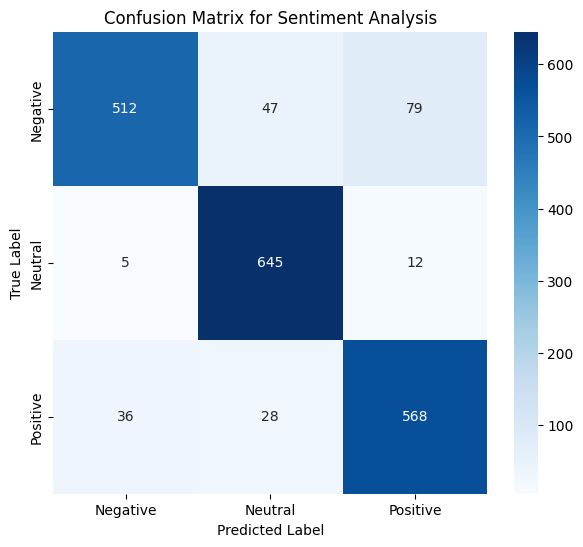


Classification Report:

              precision    recall  f1-score   support

    Negative       0.93      0.80      0.86       638
     Neutral       0.90      0.97      0.93       662
    Positive       0.86      0.90      0.88       632

    accuracy                           0.89      1932
   macro avg       0.89      0.89      0.89      1932
weighted avg       0.89      0.89      0.89      1932



In [89]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Model evaluation mode
model.eval()

all_preds = []
all_labels = []

# Turn off gradients for evaluation
with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plotting the confusion matrix
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Negative", "Neutral", "Positive"], 
            yticklabels=["Negative", "Neutral", "Positive"])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Sentiment Analysis')
plt.show()

# Classification report
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=["Negative", "Neutral", "Positive"]))

In [98]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import torch

# Model evaluation mode
model.eval()

all_preds = []
all_labels = []

# Turn off gradients for evaluation
with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ✅ Fix: use correct label names only
class_names = ["Negative", "Neutral", "Positive"]

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Save confusion matrix plot as PNG
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Sentiment Analysis')
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.close()

# Save classification report as text
report = classification_report(all_labels, all_preds, target_names=class_names)

with open("evaluation_report.txt", "w", encoding="utf-8") as f:
    f.write("Sentiment Classification Report\n")
    f.write("=" * 40 + "\n")
    f.write(report + "\n\n")
    f.write("Confusion Matrix:\n")
    f.write(str(cm))

print("✅ Classification report saved as 'evaluation_report.txt'")
print("✅ Confusion matrix image saved as 'confusion_matrix.png'")


✅ Classification report saved as 'evaluation_report.txt'
✅ Confusion matrix image saved as 'confusion_matrix.png'


In [90]:
# now saving the model 
# Save trained model and tokenizer
model_path = "saved_model_sentiment"

Tokenizer.save_pretrained(model_path)
model.save_pretrained(model_path)

print("✅ Model and tokenizer saved successfully!")

✅ Model and tokenizer saved successfully!


In [93]:
model_path="/kaggle/working/saved_model_sentiment"

In [96]:
import shutil

# Step: Zip the entire model folder
shutil.make_archive("saved_model_sentiment", 'zip', "saved_model_sentiment")

print("✅ Model folder zipped successfully!")


✅ Model folder zipped successfully!
